Descriptive Statistics
This notebook summarises the statistical information of the 128 sampled players and visualises the sample distributions.


In [1]:

import pandas as pd 
import matplotlib.pyplot as plt
import os

input_file = "sampled_Player_data.csv"
if not os.path.exists(input_file):
    raise FileNotFoundError("Run Notebook 2 first to create the stratified sample CSV.")

sample_df = pd.read_csv(input_file)

print("Sample shape:", sample_df.shape)
print(sample_df["Position_Group"].value_counts())


Sample shape: (128, 14)
Position_Group
Forward       64
Midfielder    64
Name: count, dtype: int64


In [2]:
# Descriptive statistics for SoT/90 by position.
descriptive_stats = (
    sample_df.groupby("Position_Group")["SoT/90"]
             .agg(["count", "mean", "median", "std", "min", "max"])
)

descriptive_stats["range"] = descriptive_stats["max"] - descriptive_stats["min"]

print("Descriptive Statistics for SoT/90")
display(descriptive_stats.round(4))



Descriptive Statistics for SoT/90


,count,mean,median,std,min,max,range
Position_Group,,,,,,,
Forward,64,0.6647,0.00,0.9604,0.0,4.5,4.5
Midfielder,64,0.5789,0.37,0.8077,0.0,5.0,5.0


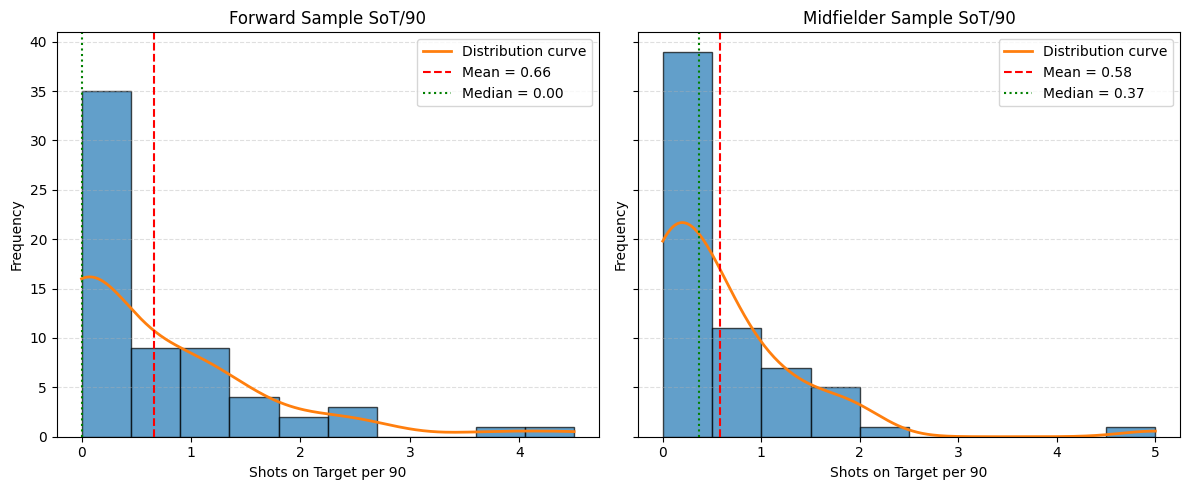

In [3]:
# Import gaussian_kde to create a smooth distribution curve
from scipy.stats import gaussian_kde
import numpy as np

# Separate histograms make the shapes easier to compare.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, position in zip(axes, ["Forward", "Midfielder"]):

    # Select the SoT/90 values for the current position group
    values = sample_df.loc[
        sample_df["Position_Group"] == position,
        "SoT/90"
    ]

    # Plot the histogram and store the histogram information
    counts, bins, patches = ax.hist(
        values,
        bins=10,
        edgecolor="black",
        alpha=0.7
    )

    # Create a smooth range of x-values covering the sample data
    x_values = np.linspace(values.min(), values.max(), 200)

    # Calculate the KDE distribution curve
    kde = gaussian_kde(values)

    # Calculate the width of each histogram bin
    bin_width = bins[1] - bins[0]

    # Scale the KDE curve so that it matches the histogram frequency scale
    kde_values = kde(x_values) * len(values) * bin_width

    # Add the smooth distribution curve to the histogram
    ax.plot(
        x_values,
        kde_values,
        linewidth=2,
        label="Distribution curve"
    )

    # Add a dashed vertical line showing the sample mean
    ax.axvline(
        values.mean(),
        linestyle="--",
        color="red",
        label=f"Mean = {values.mean():.2f}"
    )

    # Add a dotted vertical line showing the sample median
    ax.axvline(
        values.median(),
        linestyle=":",
        color="green",
        label=f"Median = {values.median():.2f}"
    )

    # Add the title and axis labels
    ax.set_title(f"{position} Sample SoT/90")
    ax.set_xlabel("Shots on Target per 90")
    ax.set_ylabel("Frequency")

    # Display the legend
    ax.legend()

    # Add horizontal grid lines to make frequencies easier to read
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# Adjust spacing between the two plots
plt.tight_layout()

# Display the figure
plt.show()


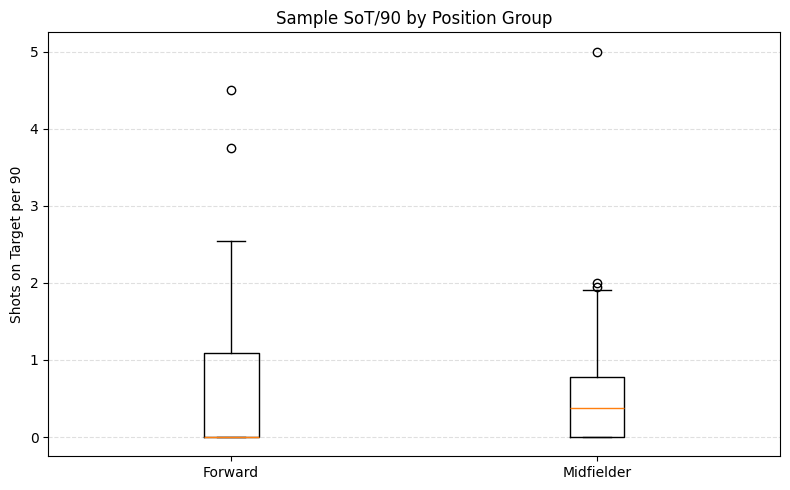

In [4]:
# Sample boxplot for a compact comparison of centre, spread and extremes.
plt.figure(figsize=(8, 5))
plt.boxplot(
    [
        sample_df.loc[sample_df["Position_Group"] == "Forward", "SoT/90"],
        sample_df.loc[sample_df["Position_Group"] == "Midfielder", "SoT/90"]
    ],
    tick_labels=["Forward", "Midfielder"]
)
plt.title("Sample SoT/90 by Position Group")
plt.ylabel("Shots on Target per 90")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
